In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

# Configuración de diseño uso efectivo de elementos de diseño)
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.max_open_warning': 0}) 

# Carga de datos
df = pd.read_csv("../data/Mental_Health_Clean_Final.csv")

# Extraemos los indicadores únicos para usarlos en nuestros loops
indicadores = df['Indicator'].unique()

## 1. Histogramas 
Usaremos un bucle `for` para generar un histograma por cada indicador disponible. Esto nos ayudará a entender cómo se distribuyen los porcentajes (`Value`) reportados y a detectar posibles anomalías.


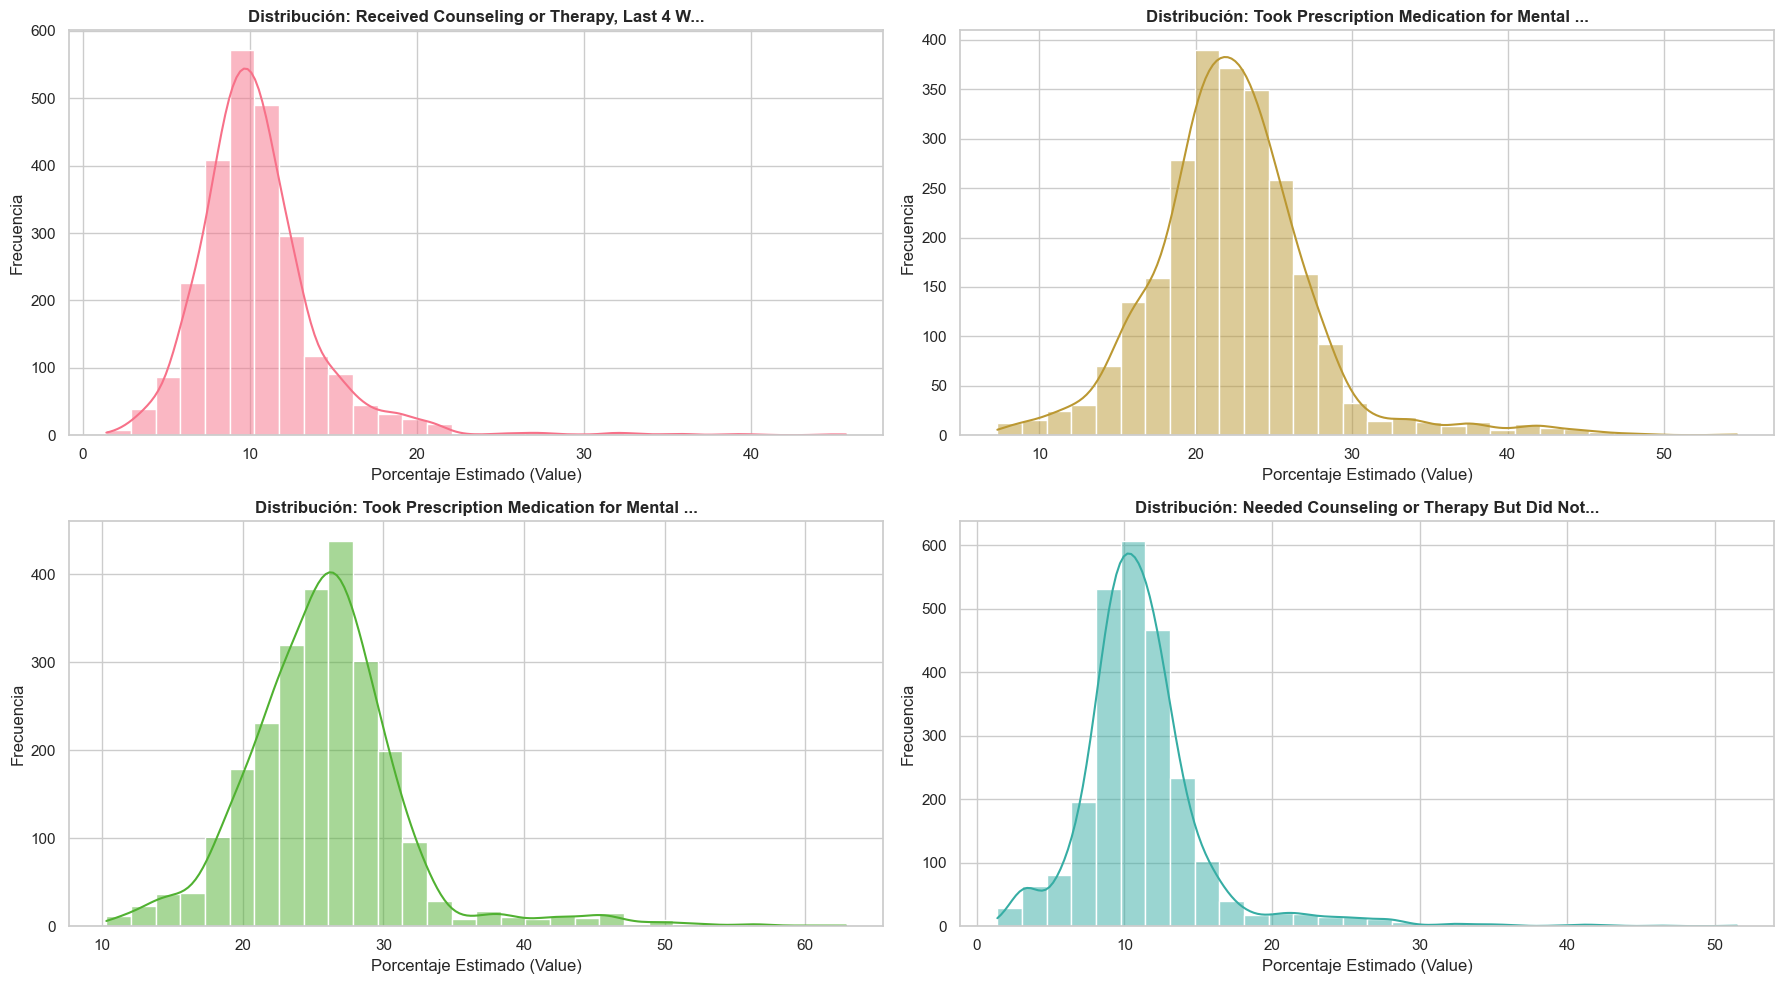

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, indicador in enumerate(indicadores):
    data_subset = df[df['Indicator'] == indicador]
    
    sns.histplot(data=data_subset, x='Value', bins=30, kde=True, ax=axes[i], color=sns.color_palette("husl")[i])
    axes[i].set_title(f'Distribución: {indicador[:40]}...', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Porcentaje Estimado (Value)')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 2. Boxplots 
Los diagramas de caja son ideales para identificar valores atípicos (outliers) y comparar la dispersión. Iteraremos sobre distintas categorías demográficas.


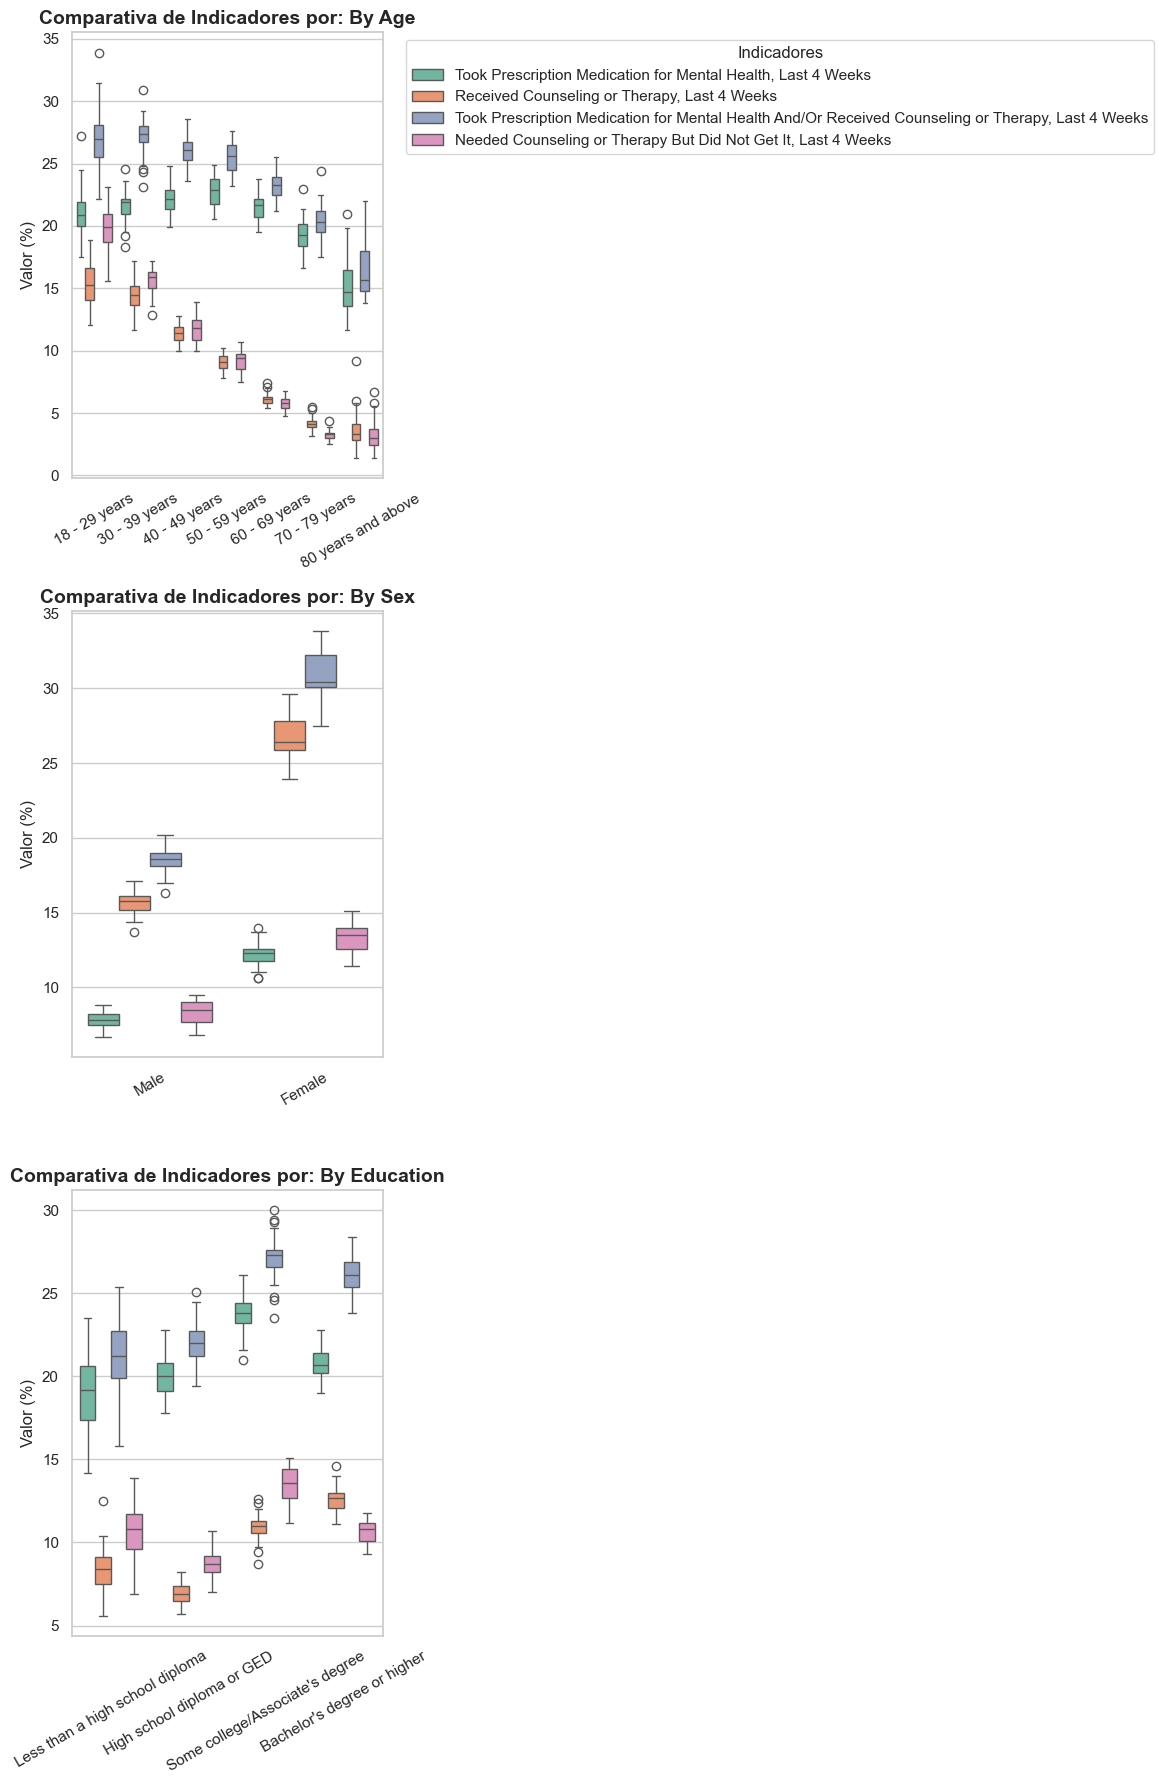

In [ ]:
categorias_demograficas = ['By Age', 'By Sex', 'By Education']

# Creamos la figura (un poco más alta para que quepa la leyenda abajo)
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

for i, categoria in enumerate(categorias_demograficas):
    data_subset = df[(df['Group'] == categoria) & (df['Indicator'].isin(indicadores))]
    
    #'hue' para diferenciar los indicadores por color
    sns.boxplot(data=data_subset, x='Subgroup', y='Value', hue='Indicator', ax=axes[i], palette="Set2")
    
    axes[i].set_title(f'Comparativa de Indicadores por: {categoria}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Valor (%)')
    axes[i].tick_params(axis='x', rotation=30)
    
    if i == 0:
        axes[i].legend(title='Indicadores', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.show()

## 3. Line Plots 
Para revelar patrones temporales, graficaremos la evolución de los indicadores a nivel nacional. El bucle iterará sobre los indicadores para generar gráficos de tendencia en el tiempo.


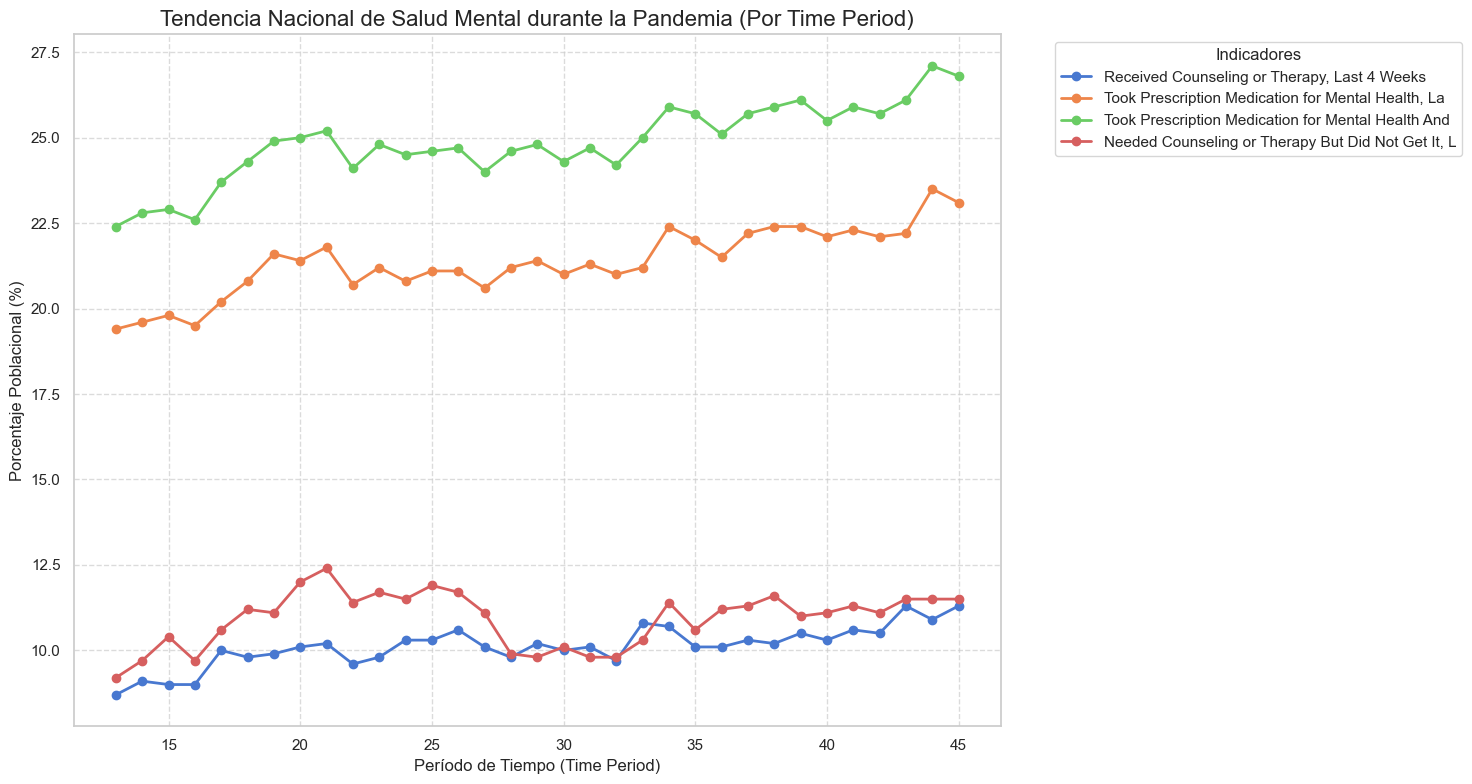

In [16]:
nacional_df = df[df['Group'] == 'National Estimate']

plt.figure(figsize=(15, 8))

for indicador in indicadores:
    data_subset = nacional_df[nacional_df['Indicator'] == indicador].sort_values(by='Time Period')
    
    # Line plot normal
    plt.plot(data_subset['Time Period'], data_subset['Value'], marker='o', linewidth=2, label=indicador[:50])

plt.title('Tendencia Nacional de Salud Mental durante la Pandemia (Por Time Period)', fontsize=16)
plt.xlabel('Período de Tiempo (Time Period)', fontsize=12)
plt.ylabel('Porcentaje Poblacional (%)', fontsize=12)
plt.legend(title='Indicadores', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 4. Scatter Plots 
Usaremos diagramas de dispersión para observar la relación entre el margen de error inferior (`LowCI`) y el porcentaje estimado (`Value`). Iteraremos sobre las fases de recolección de datos (`Phase`).



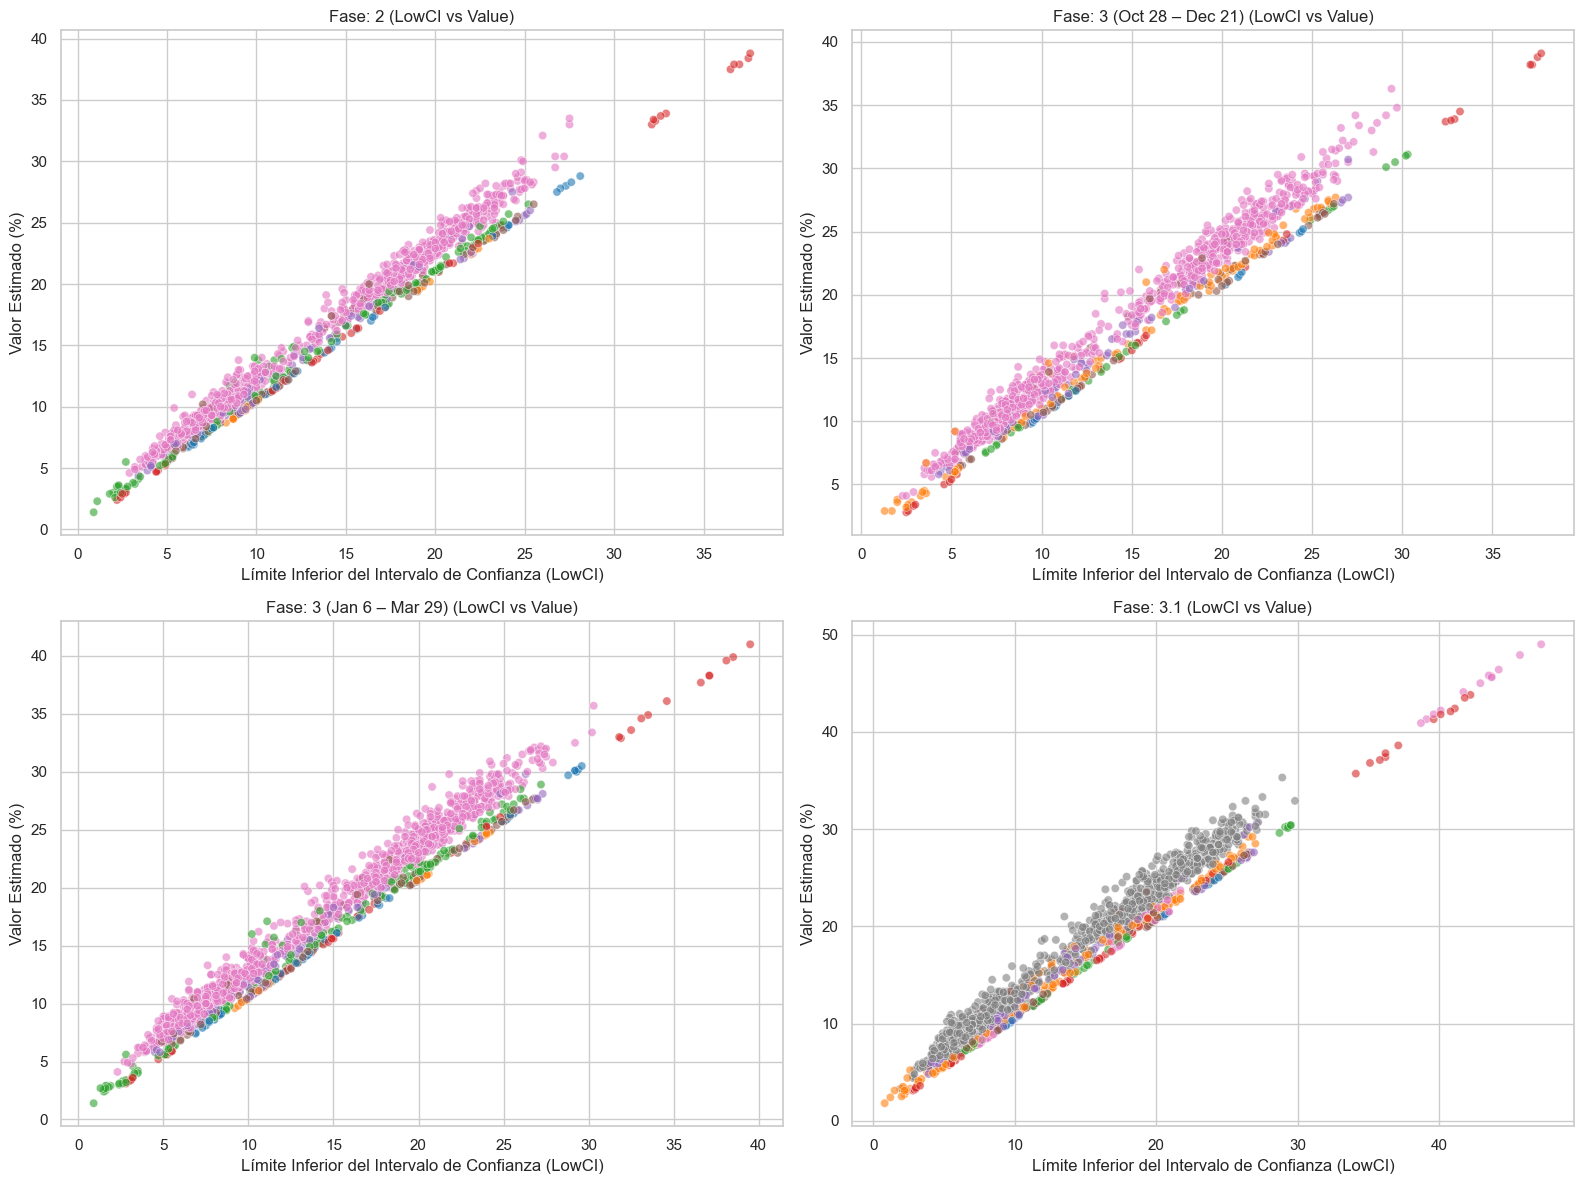

In [17]:
fases = df['Phase'].unique()[:4] # Tomamos las primeras 4 fases para el ejemplo

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, fase in enumerate(fases):
    data_subset = df[df['Phase'] == fase]
    
    sns.scatterplot(data=data_subset, x='LowCI', y='Value', hue='Group', alpha=0.6, ax=axes[i], palette="tab10")
    
    axes[i].set_title(f'Fase: {fase} (LowCI vs Value)', fontsize=12)
    axes[i].set_xlabel('Límite Inferior del Intervalo de Confianza (LowCI)')
    axes[i].set_ylabel('Valor Estimado (%)')
    axes[i].legend([],[], frameon=False) # Ocultar leyenda para no saturar

plt.tight_layout()
plt.show()

## 6. Interactividad y Funcionalidad 
Analizaremos la evolución temporal por Estado para el indicador *"Needed Counseling or Therapy But Did Not Get It"*.


In [18]:
state_data = df[(df['Group'] == 'By State') & 
                (df['Indicator'] == 'Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks')]

fig = px.line(state_data, 
              x='Time Period', 
              y='Value', 
              color='State',
              markers=True,
              title='Evolución Interactiva por Estado: Personas que necesitaron terapia pero no la obtuvieron',
              labels={'Value': 'Porcentaje (%)', 'Time Period': 'Periodo de Tiempo'},
              template='plotly_white')

fig.update_layout(
    xaxis=dict(showgrid=True),
    yaxis=dict(showgrid=True),
    legend_title_text='Estados (Haz clic para filtrar)'
)

# Para mostrar en un entorno local (Jupyter/VSCode)
fig.show()